# Orders EDA

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
pd.set_option("display.max_columns", None)

In [6]:
orders = pd.read_csv(
    "../04_Feature_Engineering/Output/orders_features.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ]
)

In [8]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_time_hours,processing_time_hours,transit_time_days,delivery_time_days,estimated_delivery_days,delivery_delay_days,delivered_on_time,purchase_month,purchase_month_number,purchase_year,purchase_quarter,purchase_day_of_week,purchase_hour,is_weekend_order,purchase_year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,56.795833,6.062650,8.436574,15.544063,-7.107488,True,October,10,2017,Q4,Monday,10,False,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,30.713889,11.109167,12.039410,13.782037,19.137766,-5.355729,True,July,7,2018,Q3,Tuesday,20,False,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.276111,4.910278,9.178113,9.394213,26.639711,-17.245498,True,August,8,2018,Q3,Wednesday,8,False,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.298056,89.900000,9.450498,13.208750,26.188819,-12.980069,True,November,11,2017,Q4,Saturday,19,True,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.030556,21.434722,1.937824,2.873877,12.112049,-9.238171,True,February,2,2018,Q1,Tuesday,21,False,2018-02


In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   approval_time_hours            99281 non-null  float64       
 9   processing_time_hours          97644 non-null  float64       
 10  transit_time_days              96475 non-null  float64       
 11  delivery_time_d

In [10]:
orders.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,approval_time_hours,processing_time_hours,transit_time_days,delivery_time_days,estimated_delivery_days,delivery_delay_days,delivered_on_time,purchase_month,purchase_month_number,purchase_year,purchase_quarter,purchase_day_of_week,purchase_hour,is_weekend_order,purchase_year_month
count,99441,99441,99441,99441,99281,97658,96476,99441,99281.000000,97644.000000,96475.000000,96476.000000,99441.000000,96476.000000,99441,99441,99441.000000,99441.000000,99441,99441,99441.000000,99441,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,12,NaN,NaN,4,7,NaN,2,25
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,August,NaN,NaN,Q2,Monday,NaN,False,2017-11
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88649,10843,NaN,NaN,29328,16196,NaN,76594,7544
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,10.419094,67.320916,9.330547,12.558702,23.767650,-11.179120,NaN,NaN,6.032220,2017.539838,NaN,NaN,14.770829,NaN,NaN
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,0.000000,-4109.256111,-16.096169,0.533414,1.648993,-146.016123,NaN,NaN,1.000000,2016.000000,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,0.215000,21.012222,4.099948,6.766403,18.331690,-16.244384,NaN,NaN,3.000000,2017.000000,NaN,NaN,11.000000,NaN,NaN
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,0.343333,43.641528,7.099769,10.217755,23.240370,-11.948941,NaN,NaN,6.000000,2018.000000,NaN,NaN,15.000000,NaN,NaN
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,14.580833,85.931250,12.029115,15.720327,28.424861,-6.390000,NaN,NaN,8.000000,2018.000000,NaN,NaN,19.000000,NaN,NaN
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,4509.180556,3018.301667,205.190972,209.628611,155.135463,188.975081,NaN,NaN,12.000000,2018.000000,NaN,NaN,23.000000,NaN,NaN


In [11]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
approval_time_hours               160
processing_time_hours            1797
transit_time_days                2966
delivery_time_days               2965
estimated_delivery_days             0
delivery_delay_days              2965
delivered_on_time                   0
purchase_month                      0
purchase_month_number               0
purchase_year                       0
purchase_quarter                    0
purchase_day_of_week                0
purchase_hour                       0
is_weekend_order                    0
purchase_year_month                 0
dtype: int64

In [12]:
orders.duplicated().sum()

0

## Univariate Analysis
### 1. Order Status Distribution
**1.1: Frequency Count**

In [13]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

**1.2: Percentage Distribution**

In [15]:
round(
    orders["order_status"].value_counts(normalize=True) * 100,
    2
)

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

**1.3: Visualization**

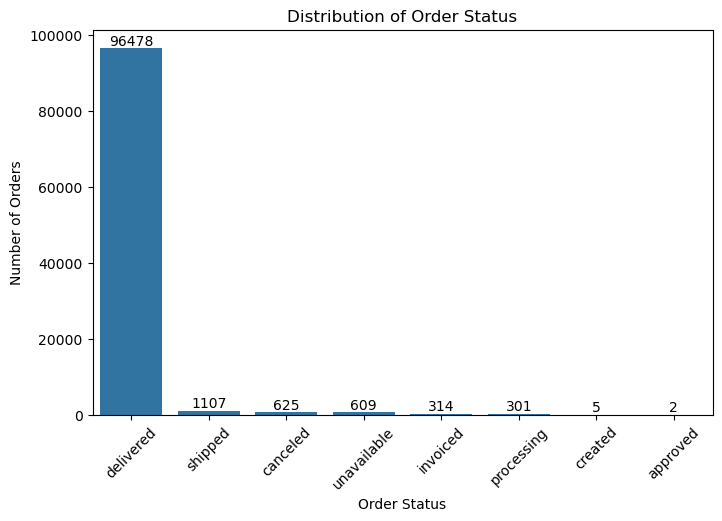

In [21]:
plt.figure(figsize=(8, 5))

ax =sns.countplot(
    data=orders,
    x="order_status",
    order=orders["order_status"].value_counts().index
)
# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

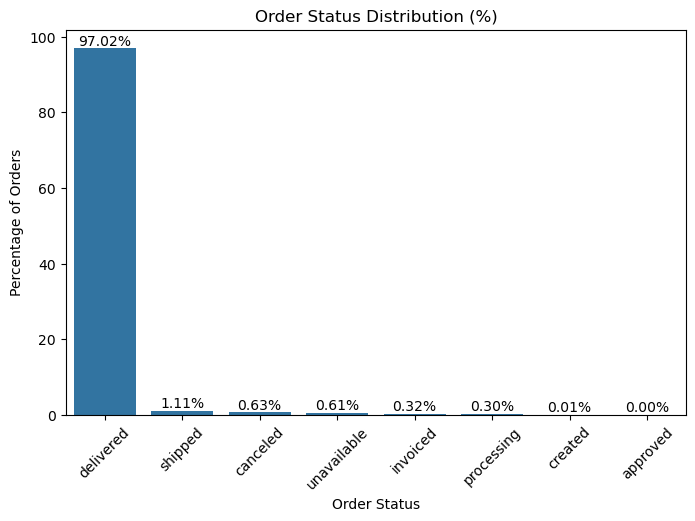

In [22]:
status_pct = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

status_pct.columns = ["order_status", "percentage"]

plt.figure(figsize=(8,5))

ax =sns.barplot(
    data=status_pct,
    x="order_status",
    y="percentage"
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("Order Status Distribution (%)")
plt.xlabel("Order Status")
plt.ylabel("Percentage of Orders")

plt.xticks(rotation=45)

plt.show()

### Obsevations and Business Insights

**Observation 1:** Delivered Orders Dominate

**Business Insight 1:**
* The overwhelming majority of orders reached customers successfully.
* This indicates that Olist's fulfillment process is generally reliable.
* Since most orders are delivered, improving delivery speed and customer satisfaction is likely to have a larger business impact than simply reducing cancellations.


**Observation 2:** Very Few Cancellations

Only 625 orders were cancelled.

**That suggests:**
* Customers rarely cancel after placing an order.
* Order processing appears relatively stable.

**Observation 3:** Unavailable Orders

There are 609 unavailable orders.

**Probable reasons could be:**
* Inventory shortages
* Seller inability to fulfill orders
* Product availability issues

**Observation 4:** Orders Still in Process

**Statuses like**

shipped
processing
invoiced
approved
created

represent orders that had not completed the full lifecycle at the time the dataset was captured.

This is expected because the dataset is effectively a snapshot in time.

### 2. approval_time_hours
   **2.1. Summary Statistics**

In [24]:
orders["approval_time_hours"].describe()

count    99281.000000
mean        10.419094
std         26.038004
min          0.000000
25%          0.215000
50%          0.343333
75%         14.580833
max       4509.180556
Name: approval_time_hours, dtype: float64

**2.2. Missing Values**

In [25]:
orders["approval_time_hours"].isnull().sum()

160

**2.3. Distribution**

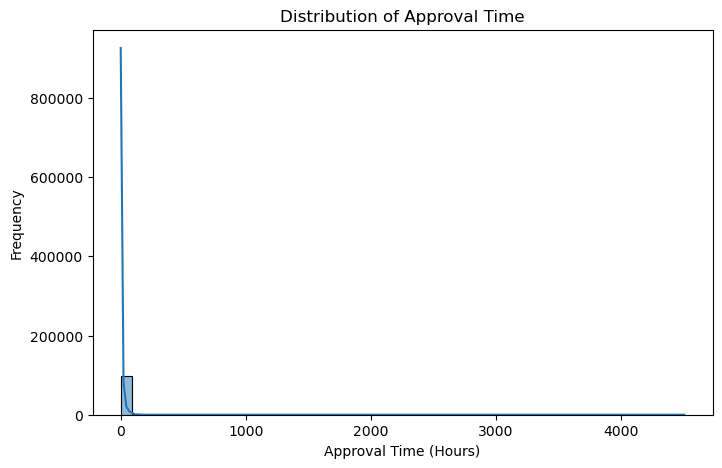

In [34]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=orders,
    x="approval_time_hours",
    bins=50,
    kde=True
)
## Below line of code could be used to look certain part of the plot clearly
## plt.xlim(0, 100)
plt.title("Distribution of Approval Time")
plt.xlabel("Approval Time (Hours)")
plt.ylabel("Frequency")

plt.show()

**2.4. Boxplot**

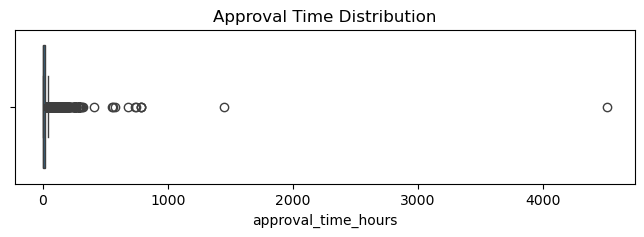

In [42]:
plt.figure(figsize=(8,2))

sns.boxplot(
    data=orders,
    x="approval_time_hours"
)

plt.title("Approval Time Distribution")

plt.show()

In [41]:
orders["approval_time_hours"].quantile([0.80,0.85,0.90,0.95])

0.80    21.328611
0.85    25.362500
0.90    34.659722
0.95    48.463611
Name: approval_time_hours, dtype: float64

In [46]:
orders.loc[
    orders["approval_time_hours"].nlargest(10).index,
    [
        "order_purchase_timestamp",
        "order_approved_at",
        "order_status",
        "approval_time_hours"
    ]
]

,order_purchase_timestamp,order_approved_at,order_status,approval_time_hours
47552,2016-10-05 18:06:48,2017-04-11 15:17:38,unavailable,4509.180556
62293,2017-02-03 00:04:49,2017-04-04 10:56:48,processing,1450.866389
4541,2016-09-04 21:15:19,2016-10-07 13:18:03,shipped,784.045556
4396,2016-09-05 00:15:34,2016-10-07 13:17:15,canceled,781.028056
43697,2018-01-18 23:14:36,2018-02-20 12:05:54,unavailable,780.855000
96251,2018-01-20 14:24:50,2018-02-20 11:51:27,delivered,741.443611
55708,2018-01-20 17:38:58,2018-02-20 12:05:54,delivered,738.448889
53475,2017-04-14 22:40:54,2017-05-13 02:45:06,canceled,676.070000
10071,2016-09-13 15:24:19,2016-10-07 13:16:46,canceled,573.874167
83143,2017-12-04 10:09:35,2017-12-27 14:03:00,processing,555.890278


**Approval Time Analysis**

The distribution of approval time is highly right-skewed. While the median approval time is approximately 0.34 hours (~21 minutes), a small number of orders required several weeks or even months for approval, resulting in a maximum approval time of approximately 4,509 hours (188 days).

Investigation of the largest values shows that these observations correspond to multiple order statuses (delivered, processing, canceled, shipped, and unavailable), suggesting that these delays are not restricted to a single outcome. These records should be retained for further investigation, as they may represent operational exceptions or historical business events rather than data errors.

### 3. processing_time_hours

**3.1. Summary Statistics**

In [48]:
orders["processing_time_hours"].describe()

count    97644.000000
mean        67.320916
std         85.186249
min      -4109.256111
25%         21.012222
50%         43.641528
75%         85.931250
max       3018.301667
Name: processing_time_hours, dtype: float64

**3.2. Missing Values**

In [49]:
orders["processing_time_hours"].isnull().sum()

1797

**3.3. Distribution**

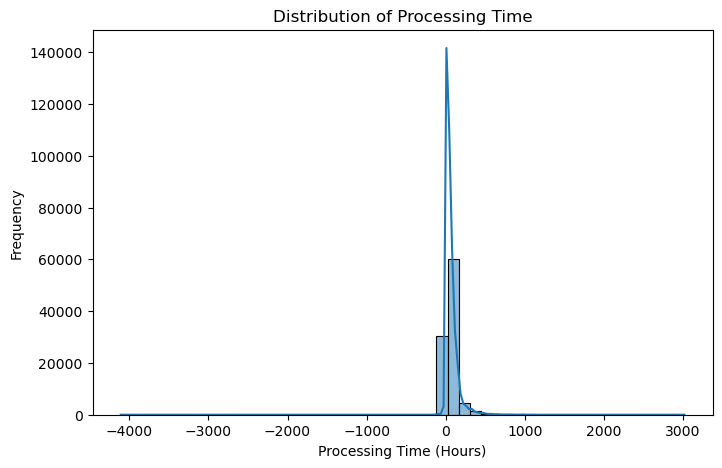

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=orders,
    x="processing_time_hours",
    bins=50,
    kde=True
)

plt.title("Distribution of Processing Time")
plt.xlabel("Processing Time (Hours)")
plt.ylabel("Frequency")

plt.show()

**3.4. Boxplot**

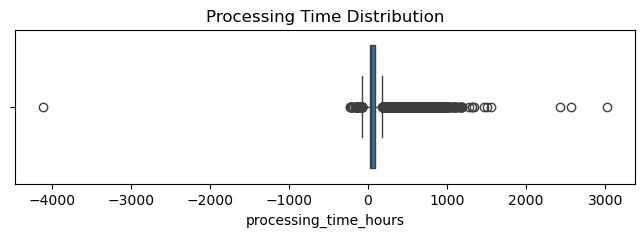

In [52]:
plt.figure(figsize=(8,2))

sns.boxplot(
    data=orders,
    x="processing_time_hours"
)

plt.title("Processing Time Distribution")

plt.show()

In [59]:
orders.loc[
    orders["processing_time_hours"].nsmallest(10).index,
    [
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_status",
        "processing_time_hours"
    ]
]

,order_approved_at,order_delivered_carrier_date,order_status,processing_time_hours
25883,2018-07-16 18:50:22,2018-01-26 13:35:00,delivered,-4109.256111
14562,2017-09-13 22:06:11,2017-09-04 13:10:23,delivered,-224.930000
46163,2017-09-13 22:17:15,2017-09-04 14:05:50,delivered,-224.190278
98710,2017-09-13 22:03:51,2017-09-04 18:07:55,delivered,-219.932222
41592,2017-09-13 21:58:04,2017-09-04 19:12:19,delivered,-218.762500
11738,2017-09-13 22:04:39,2017-09-04 20:12:41,delivered,-217.866111
85393,2017-09-13 21:58:38,2017-09-04 20:36:58,delivered,-217.361111
31211,2017-09-13 22:00:51,2017-09-04 20:49:57,delivered,-217.181667
55302,2017-09-13 21:56:08,2017-09-04 20:50:00,delivered,-217.102222
68315,2017-09-13 22:03:42,2017-09-05 11:58:18,delivered,-202.090000


In [60]:
orders.loc[
    orders["processing_time_hours"].nlargest(10).index,
    [
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_status",
        "processing_time_hours"
    ]
]

,order_approved_at,order_delivered_carrier_date,order_status,processing_time_hours
36305,2017-11-14 21:26:34,2018-03-20 15:44:40,delivered,3018.301667
35213,2017-11-29 12:41:24,2018-03-16 13:58:02,delivered,2569.277222
3077,2017-11-17 08:47:00,2018-02-26 17:27:15,delivered,2432.670833
44200,2017-11-18 02:31:11,2018-01-21 16:12:17,delivered,1549.685000
71854,2016-10-05 03:10:31,2016-12-06 17:24:00,delivered,1502.224722
95539,2017-09-06 17:15:12,2017-11-06 20:51:56,delivered,1467.612222
80357,2018-02-19 15:27:22,2018-04-16 13:54:50,delivered,1342.457778
26959,2017-01-25 16:45:21,2017-03-21 14:40:51,delivered,1317.925000
20684,2016-10-06 15:49:04,2016-11-30 10:53:48,delivered,1315.078889
30710,2016-09-15 12:16:38,2016-11-07 17:11:53,delivered,1276.920833


**Observation:** A small number of orders have negative processing times, indicating that the recorded carrier pickup timestamp precedes the order approval timestamp. These records represent timestamp inconsistencies and should be considered data quality issues. 

Additionally, a few orders exhibit exceptionally long processing times (>1000 hours), which, while chronologically valid, are rare operational outliers.

In [62]:
# Here I thought the work is repititive so I can use automation using a self defined Function:
def analyze_numeric_feature(df, column, bins=50):
    """
    Performs basic EDA for a numeric feature.
    """

    print("=" * 60)
    print(f"EDA for: {column}")
    print("=" * 60)

    # Summary Statistics
    print("\nSummary Statistics\n")
    print(df[column].describe())

    # Missing Values
    print("\nMissing Values\n")
    print(df[column].isnull().sum())

    # Histogram
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        bins=bins,
        kde=True
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

    # Boxplot
    plt.figure(figsize=(8, 2))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f"Boxplot of {column}")

    plt.show()

    # Largest Values
    print("\nTop 10 Largest Values\n")
    print(df[column].nlargest(10))

    # Smallest Values
    print("\nTop 10 Smallest Values\n")
    print(df[column].nsmallest(10))

### 4. shipping_time_hours

EDA for: transit_time_days

Summary Statistics

count    96475.000000
mean         9.330547
std          8.760122
min        -16.096169
25%          4.099948
50%          7.099769
75%         12.029115
max        205.190972
Name: transit_time_days, dtype: float64

Missing Values

2966


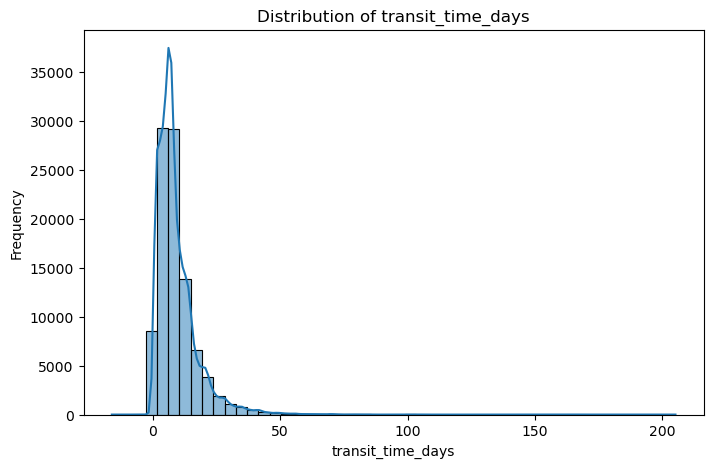

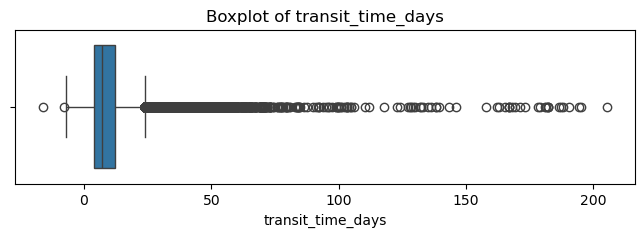


Top 10 Largest Values

55619    205.190972
19590    195.033947
89130    194.213009
70307    190.235590
61610    188.092153
54480    187.214606
81401    186.400162
62286    182.337674
68769    182.100000
31228    181.989757
Name: transit_time_days, dtype: float64

Top 10 Smallest Values

34939   -16.096169
27470    -7.878958
45302    -7.165428
14474    -6.009954
49933    -5.735984
71227    -5.690405
74967    -5.039514
41636    -4.943310
6437     -2.892384
78556    -1.984965
Name: transit_time_days, dtype: float64


In [65]:
analyze_numeric_feature(orders, "transit_time_days")

**Business Insights**

**Insight 1**
The logistics network appears efficient for the majority of orders, with most deliveries completed within one to two weeks after carrier pickup.

**Insight 2**
A small number of deliveries required several months to reach customers, suggesting exceptional logistical delays or operational edge cases that warrant further investigation.

**Insight 3**
The presence of negative transit times reveals inconsistencies in shipment and delivery timestamps. These records should be excluded from logistics KPI calculations or corrected if reliable source data is available.

### 5. delivery_time_days

EDA for: delivery_time_days

Summary Statistics

count    96476.000000
mean        12.558702
std          9.546530
min          0.533414
25%          6.766403
50%         10.217755
75%         15.720327
max        209.628611
Name: delivery_time_days, dtype: float64

Missing Values

2965


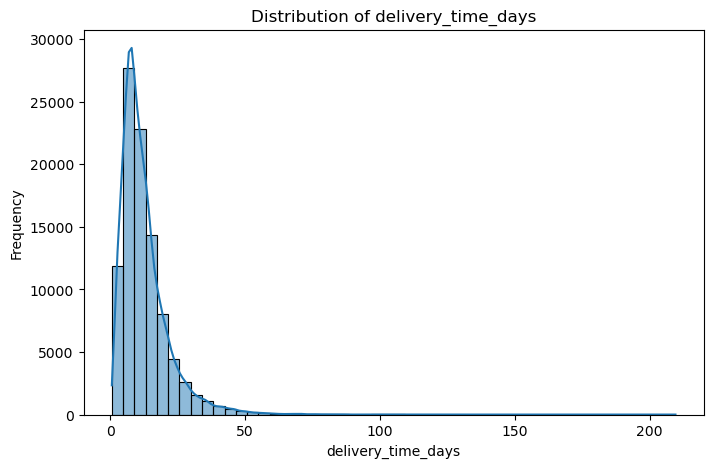

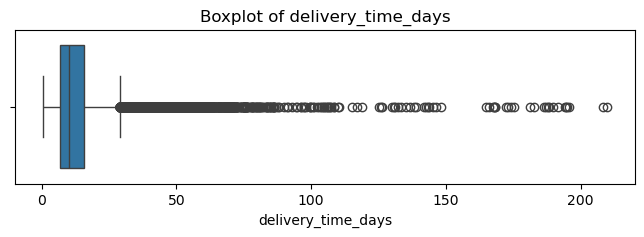


Top 10 Largest Values

19590    209.628611
55619    208.351759
61610    195.634016
70307    194.850174
89130    194.633611
38509    194.049583
11399    191.463542
81401    189.863160
54480    188.134618
68769    187.743843
Name: delivery_time_days, dtype: float64

Top 10 Smallest Values

31522    0.533414
41803    0.781366
38792    0.855313
97428    0.863426
69580    0.890752
51067    0.892488
37753    0.935984
48878    0.938183
48767    0.984375
395      0.985625
Name: delivery_time_days, dtype: float64


In [66]:
analyze_numeric_feature(orders, "delivery_time_days")

### Business Insights

**Insight 1**
Most customers receive their orders within 10–16 days of purchase, indicating a generally efficient order fulfillment process.

**Insight 2**
A small number of orders experience delivery times exceeding six months, which can significantly affect customer satisfaction and should be investigated as exceptional logistics cases.

**Insight 3**
Missing delivery time values are expected for orders that have not yet been delivered and should be excluded from delivery performance KPIs rather than treated as missing data errors.

### 6. estimated_delivery_days

EDA for: estimated_delivery_days

Summary Statistics

count    99441.000000
mean        23.767650
std          8.832371
min          1.648993
25%         18.331690
50%         23.240370
75%         28.424861
max        155.135463
Name: estimated_delivery_days, dtype: float64

Missing Values

0


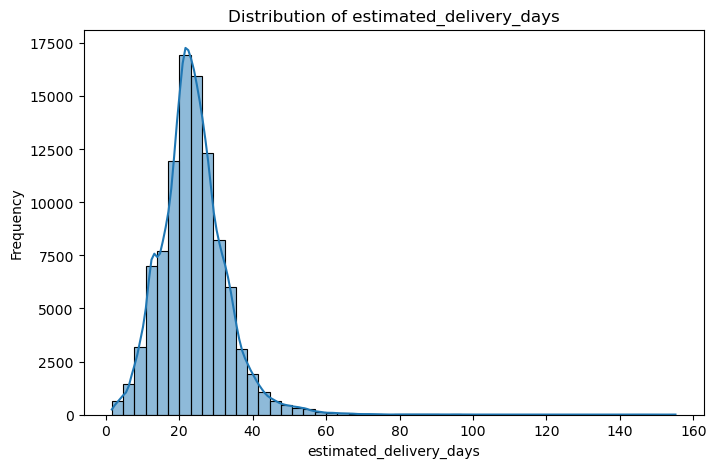

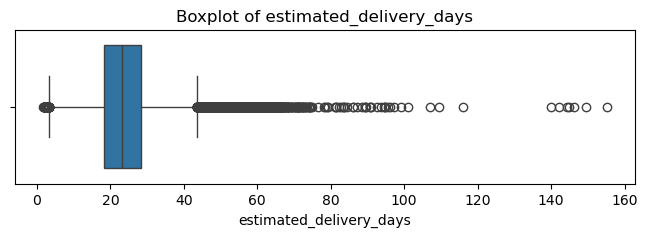


Top 10 Largest Values

57160    155.135463
40094    149.592280
15791    146.249132
36034    144.895243
33828    144.358762
55368    142.192106
86444    140.063472
67488    116.097859
14578    109.342292
9345     106.992338
Name: estimated_delivery_days, dtype: float64

Top 10 Smallest Values

53688    1.648993
10326    2.008009
42061    2.010451
12209    2.024074
19632    2.026019
15871    2.028287
73093    2.042326
66391    2.042986
63933    2.045752
77032    2.047292
Name: estimated_delivery_days, dtype: float64


In [67]:
analyze_numeric_feature(orders, "estimated_delivery_days")

**Observations**

* No missing values are present.
* The distribution is unimodal with a peak around 22–24 days.
* Most estimated delivery times lie between 18.33 and 28.42 days (IQR).
* The distribution is slightly to moderately right-skewed, with a few orders having estimated delivery times exceeding 100 days.

**Business Insights**

* Olist follows a fairly standardized delivery estimation policy, with most customers receiving an estimated delivery window of about 3–4 weeks.
* Only a small proportion of orders receive very long estimated delivery windows, likely reflecting special shipping routes, remote destinations, or products requiring longer fulfillment.
* The consistency in estimated delivery times suggests that the company has a well-defined process for setting customer delivery expectations.

### 7. delivery_delay_days

EDA for: delivery_delay_days

Summary Statistics

count    96476.000000
mean       -11.179120
std         10.186113
min       -146.016123
25%        -16.244384
50%        -11.948941
75%         -6.390000
max        188.975081
Name: delivery_delay_days, dtype: float64

Missing Values

2965


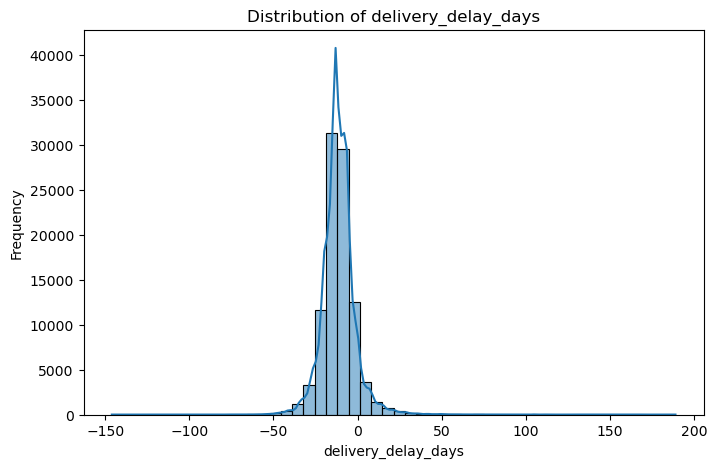

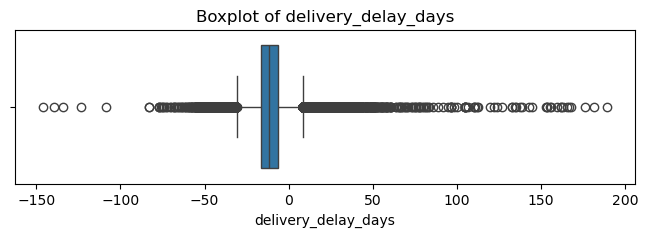


Top 10 Largest Values

55619    188.975081
19590    181.608785
11399    175.869109
81401    167.708414
89130    166.583380
61610    165.633912
68769    162.718345
40847    161.775336
38509    161.609965
54480    159.609931
Name: delivery_delay_days, dtype: float64

Top 10 Smallest Values

40094   -146.016123
15791   -139.397396
57160   -134.308530
86444   -123.433403
67488   -108.424225
79449    -83.070567
62706    -82.921829
95849    -77.324421
63537    -77.193299
37491    -77.151273
Name: delivery_delay_days, dtype: float64


In [68]:
analyze_numeric_feature(orders, "delivery_delay_days")

### Business Insights

**Insight 1**

Olist generally delivers orders well before the promised delivery date, with the typical order arriving about 12 days early.

**Insight 2**

The consistently negative delivery delay suggests that the company uses conservative delivery estimates, providing customers with a safety buffer and increasing the likelihood of meeting or exceeding expectations.

**Insight 3**

Although most deliveries are early, a small number of orders experience substantial delays. Identifying the causes of these exceptional late deliveries could further improve customer satisfaction and reduce delivery-related complaints.

## Time-Based Purchase Analysis

**1. Orders by Year**

In [69]:
orders["purchase_year"].value_counts().sort_index()

purchase_year
2016      329
2017    45101
2018    54011
Name: count, dtype: int64

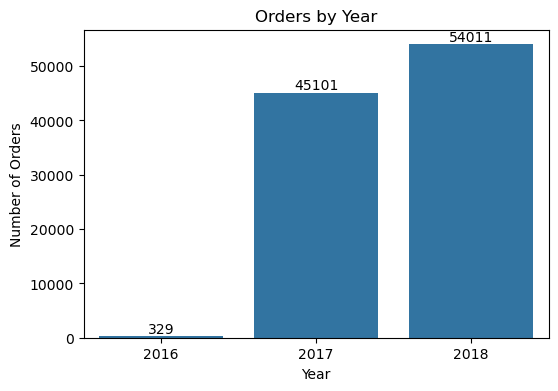

In [70]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=orders,
    x="purchase_year",
    order=sorted(orders["purchase_year"].unique())
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Orders by Year")
plt.xlabel("Year")
plt.ylabel("Number of Orders")

plt.show()

**2. Orders by Month**

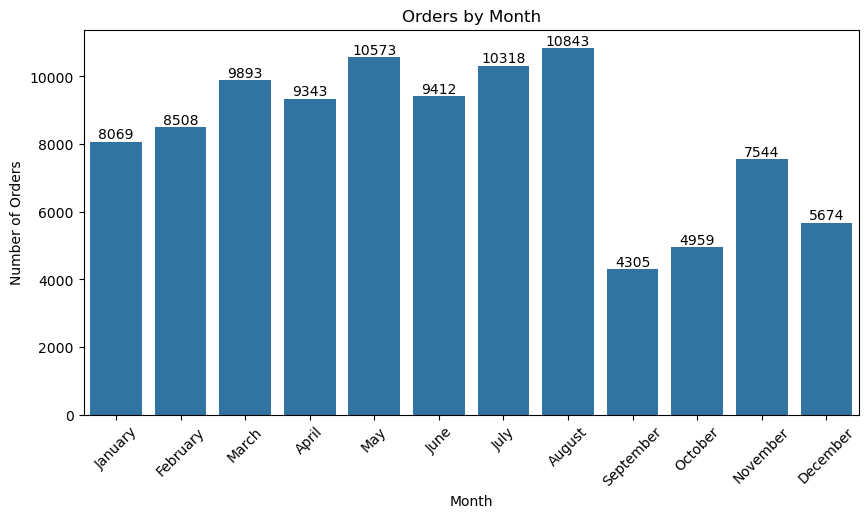

In [78]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=orders,
    x="purchase_month",
    order=month_order
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.show()

**3. Orders by Quarter**

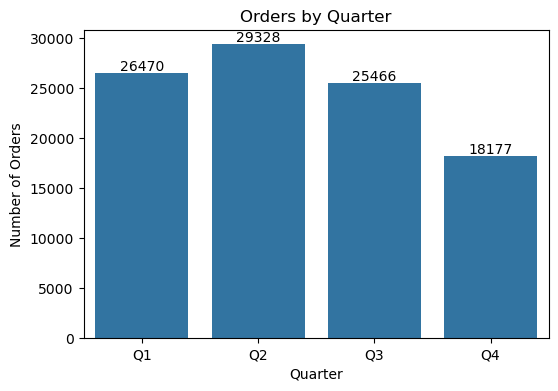

In [77]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=orders,
    x="purchase_quarter",
    order=["Q1","Q2","Q3","Q4"]
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Orders by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Number of Orders")

plt.show()

**4. Orders by Day of Week**

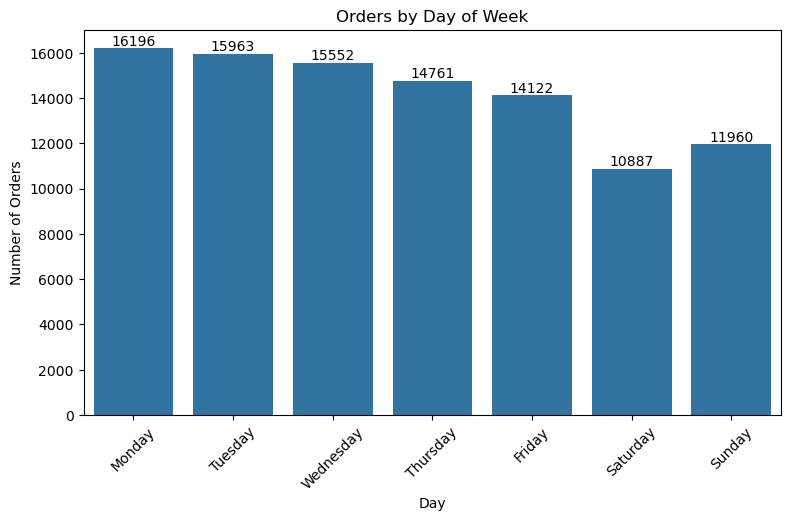

In [80]:
weekday_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

plt.figure(figsize=(9,5))

ax = sns.countplot(
    data=orders,
    x="purchase_day_of_week",
    order=weekday_order
)

for container in ax.containers:
    ax.bar_label(container)

plt.xticks(rotation=45)

plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")

plt.show()

**5. Orders by Hour**

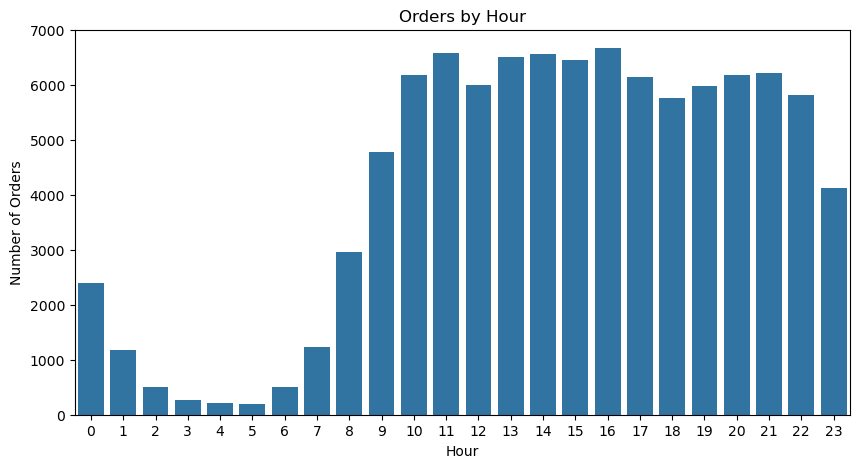

In [81]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=orders,
    x="purchase_hour"
)

plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

plt.show()

In [83]:
hourly_orders = (
    orders["purchase_hour"]
    .value_counts()
    .sort_index()
)

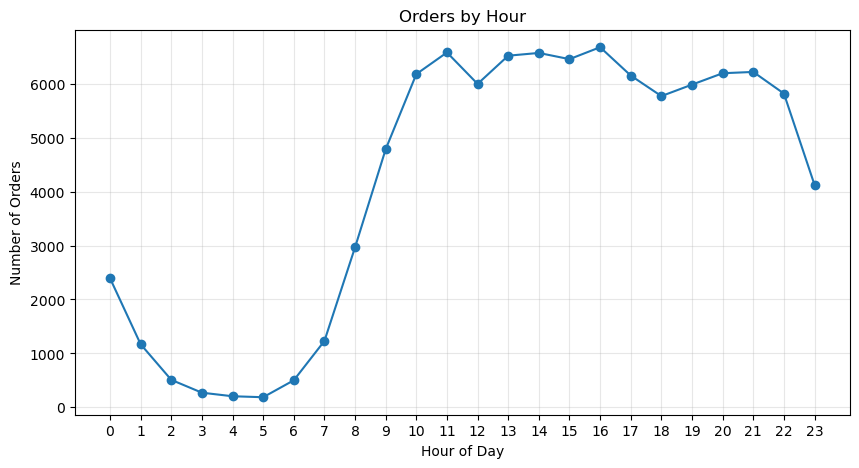

In [91]:
plt.figure(figsize=(10,5))

plt.plot(hourly_orders.index, hourly_orders.values, marker="o")

plt.title("Orders by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.xticks(range(24))

plt.grid(alpha=0.3)

plt.show()

**6. Weekend vs Weekday**

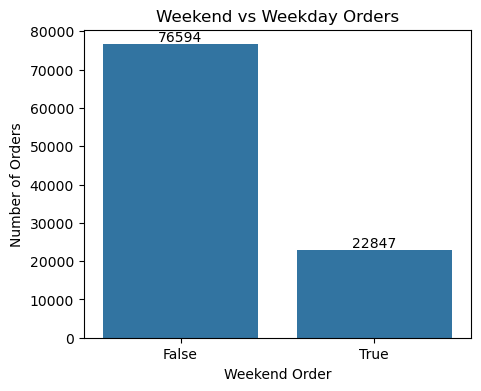

In [82]:
plt.figure(figsize=(5,4))

ax = sns.countplot(
    data=orders,
    x="is_weekend_order"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Weekend vs Weekday Orders")
plt.xlabel("Weekend Order")
plt.ylabel("Number of Orders")

plt.show()

### Purchase Time Analysis - Business Insights
**Insight 1**
The rapid increase in order volume from 2017 to 2018 indicates strong marketplace growth and increasing customer adoption.

**Insight 2**
Customer purchasing behavior follows clear temporal patterns, with the majority of orders placed during weekdays and daytime hours. These insights can support workforce planning and customer support scheduling.

**Insight 3**
Higher order activity during specific months suggests seasonal demand fluctuations. Marketing campaigns and inventory planning can be aligned with these peak periods.

**Insight 4**
Very low purchasing activity during overnight hours indicates that promotional campaigns and operational resources are likely to be most effective when focused on daytime and evening periods.